# Problema de Máxima Diversidad

Este notebook presenta una adaptación práctica del **Proyecto 9: Problema de máxima diversidad** propuesto en la oferta de trabajos de la asignatura. Originalmente enfocado en implementar un algoritmo evolutivo para maximizar la diversidad, el problema se ha trasladado al **ámbito financiero**: el objetivo es seleccionar una cartera de exactamente $m$ acciones que presenten la máxima descorrelación entre sí para minimizar el riesgo frente a caídas del mercado. El problema original de maximización se ha transformado en uno de minimización, buscando el valor negativo de la diversidad.

Para resolverlo, se extraen datos reales de las empresas del S&P 500 y se comparan dos versiones del algoritmo evolutivo para el manejo de las restricciones, tal como solicita el enunciado original:
* **AE1 (External feasibility first / Penalización)**: Aplica una penalización estricta sobre la función objetivo si la cartera generada no cumple con el número exacto de activos requeridos ($m$).
* **AE2 (Algoritmo de reparo)**: Utiliza una heurística que ajusta o "repara" dinámicamente los cromosomas generados (comprando o vendiendo activos al azar) para que la cartera cumpla con la restricción antes de evaluar su *fitness*.

Finalmente, el rendimiento algorítmico y la robustez de ambas técnicas se evalúan estadísticamente bajo diferentes escenarios de inversión (carteras pequeñas, medianas e institucionales) haciendo uso del test no paramétrico de Wilcoxon.

Primero importamos las librerías necesarias para el notebook.

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import random
from scipy.stats import wilcoxon
import warnings
import logging

warnings.filterwarnings('ignore')
logger = logging.getLogger('yfinance')
logger.setLevel(logging.CRITICAL)

Para este notebook se usarán datos reales, por lo que extraeremos desde Wikipedia los integrantes del índice bursatil S&P500 y nos descargaremos dos años de historia para cada uno. Calcularemos los retornos diarios y la matriz de correlación entre ellos, a partir de la cual crearemos la matriz de distancias.

In [11]:
def get_tickers():
    URL = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
    sp500_df = pd.read_csv(URL)
    sp500_tickers = sp500_df['Symbol'].tolist()
    sp500_tickers = [str(ticker).replace('.', '-') for ticker in sp500_tickers]
    return sp500_tickers

def download_data(tickers):
    data = yf.download(tickers, start="2022-01-01", end="2024-01-01", progress=False, auto_adjust=False)['Adj Close']
    return data

def process_data(data):
    returns = data.pct_change().dropna(axis=0, how='all').dropna(axis=1)
    if returns.shape[1] >= 200:
        valid_tickers = returns.columns.tolist()[:200]
        returns = returns[valid_tickers]
    else:
        valid_tickers = returns.columns.tolist()
    return returns, valid_tickers

def get_correlation_matrix(returns):
    corr_matrix = returns.corr().values
    return corr_matrix

def get_distance_matrix(corr_matrix):
    distance_matrix = 1 - corr_matrix
    return distance_matrix

In [12]:
tickers = get_tickers()
data = download_data(tickers)
returns, tickers = process_data(data)
corr_matrix = get_correlation_matrix(returns)
master_distance_matrix = get_distance_matrix(corr_matrix)

Definimos a continuación las funciones necesarias para el algoritmo evolutivo. Se utiliza selección por torneo, cruze uniforme y mutación por flip bit de probabilidad fija. La selección por torneo se implementa con un tamaño de torneo de 3, lo que significa que se seleccionan aleatoriamente 3 individuos de la población y se elige el mejor entre ellos para reproducirse. El cruce uniforme combina dos padres para crear un hijo, donde cada gen del hijo tiene una probabilidad del 50% de ser heredado de cada padre en el caso de que ocurra el cruce con una probabilidad fija. La mutación por flip bit consiste en cambiar el valor de un gen específico con una probabilidad fija, lo que introduce variabilidad en la población y ayuda a evitar la convergencia prematura.

In [13]:
def init_population(pop_size, n):
    """Inicializa la población aleatoriamente (ceros y unos)."""
    return [np.random.randint(2, size=n) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=3):
    """Selección por torneo (buscamos minimizar el fitness)."""
    selected = random.sample(range(len(population)), k)
    best_idx = min(selected, key=lambda i: fitnesses[i])
    return population[best_idx].copy()

def uniform_crossover(p1, p2, pc=0.6):
    """Cruce uniforme estocástico."""
    if random.random() < pc:
        c1, c2 = p1.copy(), p2.copy()
        mask = np.random.randint(2, size=len(p1))
        c1[mask == 1] = p2[mask == 1]
        c2[mask == 1] = p1[mask == 1]
        return c1, c2
    return p1.copy(), p2.copy()

def bit_flip_mutation(ind, pm):
    """Mutación bit-flip con probabilidad pm."""
    mask = np.random.random(len(ind)) < pm
    ind[mask] = 1 - ind[mask]
    return ind

Primero tomaremos un enfoque de minimización de riesgo. En finanzas, para blindar una cartera contra caídas del mercado, el gestor busca seleccionar un número exacto de $m$ acciones que presenten la máxima descorrelación entre sí. Sin embargo, los algoritmos de optimización están diseñados por defecto para resolver problemas de minimización. Transformamos el problema: en lugar de buscar el máximo de la diversidad, le decimos al algoritmo que minimice el valor negativo de la diversidad. Buscar el valor más bajo (el número negativo más grande) resulta en la máxima descorrelación real. Aplicando "External Feasibility First", reducimos el espacio de búsqueda a solo combinaciones de $m$ acciones, lo que mejora la eficiencia del algoritmo al enfocarse únicamente en soluciones viables.

Matemáticamente, la función objetivo que el algoritmo intenta minimizar se define de la siguiente manera:$$F(x) = \begin{cases} -\sum_{i=1}^{n-1}\sum_{j=i+1}^{n} d_{ij} x_{i} x_{j} & \text{si } \sum_{i=1}^{n} x_{i} = m \\ \left| \sum_{i=1}^{n} x_{i} - m \right| & \text{en otro caso} \end{cases}$$

Las distancias son las calculadas anteriormente a partir de la matriz de correlación. La función objetivo penaliza cualquier solución que no cumpla con la restricción de seleccionar exactamente $m$ acciones, asegurando que el algoritmo se enfoque en encontrar la combinación de acciones que maximice la descorrelación dentro del espacio de soluciones factibles.

Si la cartera es válida (la suma de acciones seleccionadas $x_i$ es exactamente $m$): El algoritmo calcula la distancia total $d_{ij}$ entre todos los pares de acciones seleccionadas y le pone un signo negativo. Al intentar hacer este número lo más "pequeño" (negativo) posible, maximiza nuestra protección defensiva. Si la cartera es inválida (tiene más o menos de $m$ acciones): El algoritmo actúa como un gestor de riesgos estricto. Ignora la rentabilidad o diversidad de las acciones y aplica una penalización, calculando simplemente la diferencia absoluta entre las acciones que tienes y las que deberías tener. Como este valor de penalización siempre será positivo (y por tanto "mayor" y peor que cualquier valor negativo), el algoritmo aprende rápidamente a descartar estas carteras ilegales en las siguientes generaciones.

In [14]:
# Enfoque AE1
def evaluate_ae1(ind, dist_matrix, m):
    """
    AE1: Penalización si no se cumple la restricción de sumar m.
    """
    selected_indices = np.where(ind == 1)[0]
    
    if len(selected_indices) == m:
        # Calcular la suma de distancias
        dist_sum = 0
        for i in range(len(selected_indices)):
            for j in range(i + 1, len(selected_indices)):
                dist_sum += dist_matrix[selected_indices[i], selected_indices[j]]
        # Retornamos negativo porque el AE minimizará la función.
        return -dist_sum
    else:
        # Penalización: distancia a m (siempre será positivo, por lo que será un mal fitness).
        return abs(np.sum(ind) - m)

El segundo enfoque explorado simula la acción de un bróker que "rebalancea" la cartera. Antes de evaluar la descorrelación de la cartera, el algoritmo aplica un operador heurístico de reparación: si el cruce genético ha generado una cartera con sobreexposición (más de $m$ acciones), vende (cambia a 0) activos al azar hasta llegar a $m$. Si la cartera está subexpuesta (menos de $m$ acciones), compra (cambia a 1) activos al azar.Una vez la cartera cumple estrictamente las reglas del fondo, se evalúa su función objetivo (minimizando de nuevo el valor negativo de la suma de sus distancias). Esto garantiza que el algoritmo no desperdicie recursos computacionales evaluando carteras que en el mundo real no serían legales o válidas para el cliente.

In [15]:
def repair_chromosome(ind, m):
    """Repara el cromosoma para que tenga exactamente m unos."""
    repaired = ind.copy()
    current_ones = np.sum(repaired)
    
    if current_ones > m:
        # Sobran unos, los cambiamos a cero aleatoriamente
        ones_indices = np.where(repaired == 1)[0]
        to_zero = np.random.choice(ones_indices, current_ones - m, replace=False)
        repaired[to_zero] = 0
    elif current_ones < m:
        # Faltan unos, cambiamos ceros a unos aleatoriamente
        zeros_indices = np.where(repaired == 0)[0]
        to_one = np.random.choice(zeros_indices, m - current_ones, replace=False)
        repaired[to_one] = 1
        
    return repaired

def evaluate_ae2(ind, dist_matrix, m):
    """
    AE2: Reparamos el individuo y luego calculamos su fitness real.
    """
    repaired_ind = repair_chromosome(ind, m)
    selected_indices = np.where(repaired_ind == 1)[0]
    
    dist_sum = 0
    for i in range(len(selected_indices)):
        for j in range(i + 1, len(selected_indices)):
            dist_sum += dist_matrix[selected_indices[i], selected_indices[j]]
            
    return -dist_sum # Negativo para minimizar

El bucle iterativo de la función siguiente somete a las carteras a un proceso de selección natural donde solo sobreviven aquellas combinaciones de acciones que logran el menor valor objetivo (es decir, el escudo de descorrelación más potente).

Para asegurar la convergencia hacia la cartera óptima, utilizamos elitismo: la composición de la mejor cartera histórica se guarda intacta y pasa directamente a la siguiente generación, impidiendo que el azar del mercado (los operadores de cruce y mutación) destruya una solución defensiva perfecta que se había encontrado.

In [16]:
def run_evolutionary_algorithm(eval_func, dist_matrix, n, m, pop_size=50, generations=100, pc=0.6):
    pm = 1 / n # Probabilidad de mutación.
    population = init_population(pop_size, n)
    
    best_fitness_history = []
    global_best_fitness = float('inf')
    global_best_ind = None
    
    for gen in range(generations):
        # Evaluar población.
        fitnesses = [eval_func(ind, dist_matrix, m) for ind in population]
        
        # Guardar el mejor.
        min_fit_idx = np.argmin(fitnesses)
        if fitnesses[min_fit_idx] < global_best_fitness:
            global_best_fitness = fitnesses[min_fit_idx]
            global_best_ind = population[min_fit_idx].copy()
            
        best_fitness_history.append(global_best_fitness)
        
        # Nueva generación.
        new_population = []
        # Elitismo. 
        new_population.append(global_best_ind.copy())
        
        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            
            c1, c2 = uniform_crossover(p1, p2, pc)
            
            c1 = bit_flip_mutation(c1, pm)
            c2 = bit_flip_mutation(c2, pm)
            
            new_population.extend([c1, c2])
            
        population = new_population[:pop_size]
        
    return -global_best_fitness, best_fitness_history, global_best_ind

Para demostrar la robustez de nuestros dos enfoques (Penalización vs. Reparación), diseñamos un stress test que evalúa el algoritmo bajo tres universos de inversión distintos:

* Cartera Pequeña (10 acciones de un índice de 100).

* Cartera Mediana (15 acciones de un índice de 150).

* Cartera Institucional (20 acciones de un índice de 200).

Debido a la naturaleza estocástica (aleatoria) de los algoritmos evolutivos, corremos 10 simulaciones (runs) por cada tamaño y enfoque, utilizando semillas fijas. Esto asegura que la comparación sea estadísticamente justa y represente un comportamiento real sostenido, no un simple golpe de suerte.

In [ ]:
# Definición de los 3 problemas de test
test_cases = [
    {"name": "Pequeña", "n": 100, "m": 10},
    {"name": "Mediana", "n": 150, "m": 15},
    {"name": "Institucional", "n": 200, "m": 20}
]

num_runs = 10
generations = 150
pop_size = 50

# Diccionario para almacenar todos los resultados.
all_results = {}

for case in test_cases:
    n_test = case["n"]
    m_test = case["m"]
    case_name = case["name"]
    
    # Recortamos la matriz maestra para adaptarla al tamaño n del problema actual
    current_dist_matrix = master_distance_matrix[:n_test, :n_test]
    
    res_ae1, hist_ae1 = [], []
    res_ae2, hist_ae2 = [], []
    
    # Ejecuciones AE1
    for i in range(num_runs):
        np.random.seed(i)
        random.seed(i)
        best_fit, hist, _ = run_evolutionary_algorithm(evaluate_ae1, current_dist_matrix, n_test, m_test, pop_size, generations)
        res_ae1.append(best_fit)
        hist_ae1.append(hist)
        
    # Ejecuciones AE2
    for i in range(num_runs):
        np.random.seed(i)
        random.seed(i)
        best_fit, hist, _ = run_evolutionary_algorithm(evaluate_ae2, current_dist_matrix, n_test, m_test, pop_size, generations)
        res_ae2.append(best_fit)
        hist_ae2.append(hist)
        
    # Guardamos los resultados del caso de prueba
    all_results[case_name] = {
        "n": n_test, "m": m_test,
        "AE1_res": res_ae1, "AE1_hist": hist_ae1,
        "AE2_res": res_ae2, "AE2_hist": hist_ae2
    }

Para comparar estadísticamente los resultados obtenidos por ambos enfoques, aplicamos la prueba de Wilcoxon. Esta prueba
no paramétrica evalúa si las diferencias entre los resultados de los dos enfoques son estadísticamente significativas, sin asumir una distribución normal de los datos. Al analizar los resultados de las 10 simulaciones para cada tamaño de cartera, podemos determinar si uno de los enfoques ofrece consistentemente mejores resultados en términos de la función objetivo (diversidad financiera) que el otro. Un valor p bajo (generalmente menor a 0.05) indicaría que las diferencias observadas no son producto del azar, sino que reflejan una verdadera diferencia en el rendimiento de los enfoques de penalización y reparación.

In [19]:
# Reporte de resultados
for case_name, data in all_results.items():
    r_ae1 = data["AE1_res"]
    r_ae2 = data["AE2_res"]
    
    print(f"\n[ Cartera {case_name} | n={data['n']}, m={data['m']} ]")
    print(f"AE1 (Penalización): Media={np.mean(r_ae1):.2f} | Max={np.max(r_ae1):.2f} | Min={np.min(r_ae1):.2f} | Std={np.std(r_ae1):.2f}")
    print(f"AE2 (Reparación):   Media={np.mean(r_ae2):.2f} | Max={np.max(r_ae2):.2f} | Min={np.min(r_ae2):.2f} | Std={np.std(r_ae2):.2f}")
    
    # Test estadístico
    stat, p_value = wilcoxon(r_ae1, r_ae2)
    sig = "SÍ" if p_value < 0.05 else "NO"
    print(f">> Test Wilcoxon p-value: {p_value:.4f} -> ¿Diferencia Significativa? {sig}")


[ Cartera Pequeña | n=100, m=10 ]
AE1 (Penalización): Media=37.12 | Max=37.67 | Min=36.74 | Std=0.25
AE2 (Reparación):   Media=36.91 | Max=37.39 | Min=36.49 | Std=0.28
>> Test Wilcoxon p-value: 0.0645 -> ¿Diferencia Significativa? NO

[ Cartera Mediana | n=150, m=15 ]
AE1 (Penalización): Media=86.28 | Max=87.26 | Min=85.53 | Std=0.52
AE2 (Reparación):   Media=84.82 | Max=85.91 | Min=83.96 | Std=0.61
>> Test Wilcoxon p-value: 0.0020 -> ¿Diferencia Significativa? SÍ

[ Cartera Institucional | n=200, m=20 ]
AE1 (Penalización): Media=151.16 | Max=154.36 | Min=149.04 | Std=1.31
AE2 (Reparación):   Media=149.45 | Max=151.58 | Min=146.28 | Std=1.50
>> Test Wilcoxon p-value: 0.0059 -> ¿Diferencia Significativa? SÍ


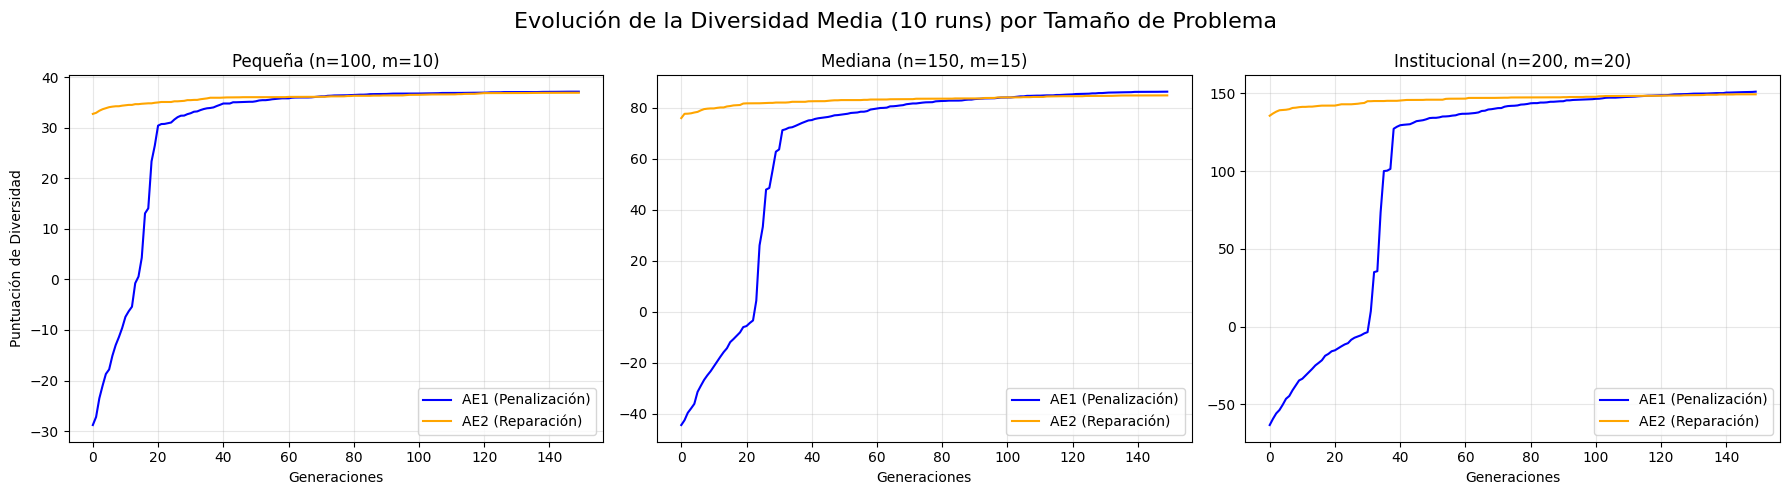

In [ ]:
# Visualización Gráfica (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evolución de la Diversidad Media (10 runs) por Tamaño de Problema', fontsize=16)

for idx, (case_name, data) in enumerate(all_results.items()):
    ax = axes[idx]
    
    # Invertimos el signo para graficar maximización
    mean_h_ae1 = np.mean(np.array(data["AE1_hist"]) * -1, axis=0)
    mean_h_ae2 = np.mean(np.array(data["AE2_hist"]) * -1, axis=0)
    
    ax.plot(mean_h_ae1, label="AE1 (Penalización)", color='blue')
    ax.plot(mean_h_ae2, label="AE2 (Reparación)", color='orange')
    
    ax.set_title(f"{case_name} (n={data['n']}, m={data['m']})")
    ax.set_xlabel("Generaciones")
    if idx == 0:
        ax.set_ylabel("Puntuación de Diversidad")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

Observando la gráfica, se puede ver como el enfoque de penalización comienza con peores valores de diversidad, pero rápidamente mejora para converger a una solución más óptima. El enfoque de reparación es mucho más estable en principio, manteniendose cerca del óptimo desde el inicio, pero no logra alcanzar la misma calidad de solución que el enfoque de penalización. Esto se debe a que el enfoque de reparación, al corregir las carteras antes de evaluarlas, limita la exploración del espacio de soluciones, lo que puede impedir que el algoritmo descubra combinaciones de acciones altamente descorrelacionadas que inicialmente eran inviables. En contraste, el enfoque de penalización permite una mayor diversidad en las soluciones exploradas, lo que facilita la convergencia hacia una cartera con mayor diversidad financiera. Véase como el test de Wilcoxon confirma que las diferencias entre ambos enfoques son estadísticamente significativas, respaldando la conclusión de que el enfoque de penalización es superior en este caso.